# Seasonal Patterns in Agricultural Performance

## Data Analytics Study

**Field:** Agriculture

**Study Focus:** Seasonal Variation in Agricultural Activities and Outcomes

**Analytical Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Problem Statement

Agricultural performance can vary from one season to another because farming conditions, weather, available resources, cultivation practices, and market situations are not the same throughout the year. These variations can influence crop production, resource consumption, and the financial results of farming activities.

The available agricultural dataset contains information from different seasons, crops, locations, environmental conditions, and farming activities. By analyzing this information, the project aims to understand how agricultural performance changes with seasons and to identify meaningful patterns, differences, and relationships within the data.

## Project Objectives

- To understand the structure and important characteristics of the agricultural dataset.
- To clean and prepare the data for reliable analysis.
- To study how agricultural performance differs across seasons.
- To examine seasonal changes in environmental conditions and farming activities.
- To compare resource usage and economic performance between seasons.
- To identify patterns, trends, relationships, and variations in the data.
- To compare agricultural performance across different crops and regions.
- To identify unusual or significant seasonal observations.
- To present the findings using suitable statistical methods and visualizations.
- To develop evidence-based conclusions and recommendations for better seasonal agricultural planning.

## Dataset Overview

The dataset contains farm-level agricultural records collected across different seasons and geographical regions. It brings together information related to crops, farming practices, environmental conditions, resource usage, production, and financial performance.

The dataset includes variables such as crop type, season, farm area, rainfall, temperature, humidity, soil characteristics, irrigation method, fertilizers, pesticides, crop yield, production, market price, costs, revenue, profit, and water usage.

This dataset provides a suitable basis for studying seasonal changes in agricultural performance and comparing how different farming and environmental factors vary across seasons.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style="whitegrid")

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [3]:
# Load the agricultural dataset

df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
print("Dataset Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:
1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


In [7]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [8]:
categorical_columns = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']

for column in categorical_columns:
    print(f"\n{column}:")
    print("Number of unique values:", df[column].nunique())
    print(df[column].unique())


State:
Number of unique values: 8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
Number of unique values: 10
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
Number of unique values: 8
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
Number of unique values: 3
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
Number of unique values: 4
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [11]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

print("Missing values have been handled using median imputation.")

Missing values have been handled using median imputation.


In [12]:
print("Total missing values after cleaning:", df.isnull().sum().sum())

Total missing values after cleaning: 0


In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns

outlier_summary = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower_bound) |
                     (df[column] > upper_bound)).sum()

    outlier_summary[column] = outlier_count

outlier_summary = pd.Series(outlier_summary)

print("Columns with detected extreme values:")
print(outlier_summary[outlier_summary > 0])

Columns with detected extreme values:
Avg_Temperature_C                  2
Humidity_pct                       6
Sunlight_Hours_Day                26
Soil_Moisture_pct                  5
Nitrogen_kg_ha                    10
Phosphorus_kg_ha                  16
Potassium_kg_ha                   32
Fertilizer_kg_ha                  15
Pesticide_Litre_ha                 8
Yield_Tonnes_Ha                  302
Production_Tonnes                333
Revenue_INR                      240
Profit_INR                       404
Water_Used_m3                    276
Water_Efficiency_t_per_1000m3    322
Disease_Pest_Risk_pct             10
dtype: int64


In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate records:", df.duplicated().sum())

Rows: 4000
Columns: 28
Missing values: 0
Duplicate records: 0


In [15]:
season_counts = df['Season'].value_counts()

print("Number of records by season:")
print(season_counts)

Number of records by season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


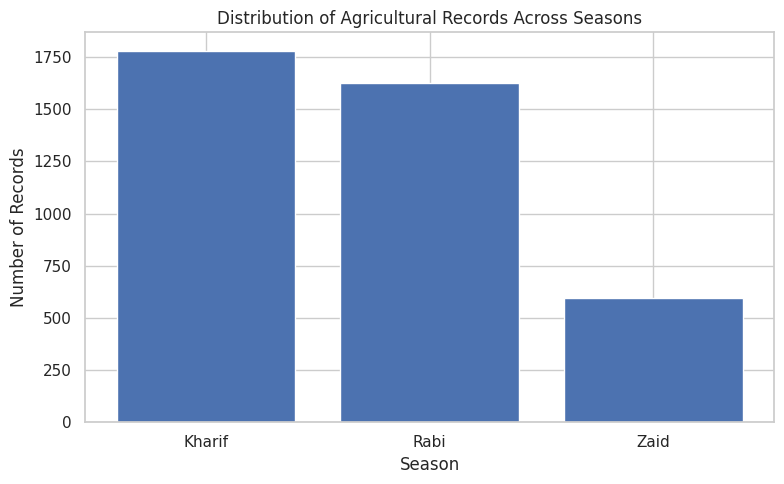

In [16]:
plt.figure(figsize=(8, 5))

season_counts = df['Season'].value_counts()

plt.bar(season_counts.index, season_counts.values)

plt.title('Distribution of Agricultural Records Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

In [17]:
season_performance = df.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']
].mean().round(2)

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Season,,,
Kharif,5.63,46.31,"178,914.65"
Rabi,5.04,41.49,"87,689.47"
Zaid,4.64,38.89,"-24,804.82"


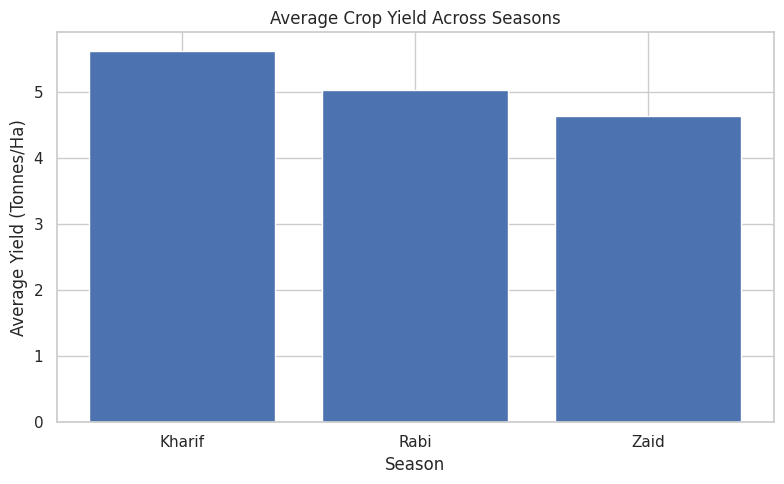

In [18]:
yield_by_season = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

plt.figure(figsize=(8, 5))

plt.bar(yield_by_season.index, yield_by_season.values)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

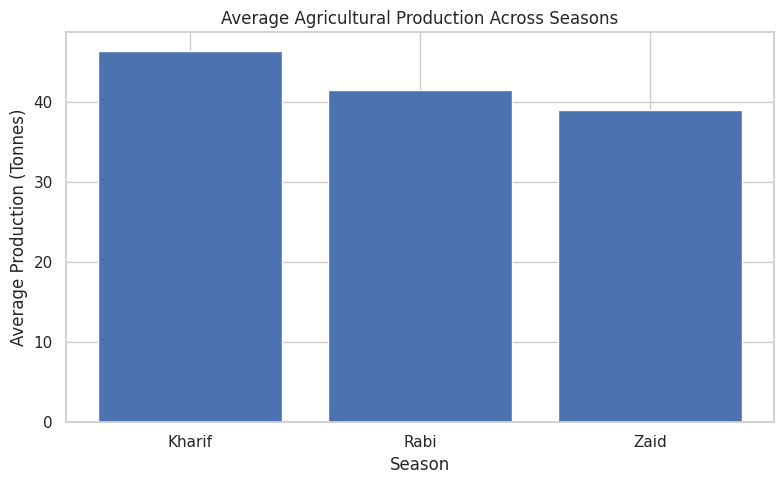

In [19]:
production_by_season = df.groupby('Season')['Production_Tonnes'].mean()

plt.figure(figsize=(8, 5))

plt.bar(production_by_season.index, production_by_season.values)

plt.title('Average Agricultural Production Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')

plt.tight_layout()
plt.show()

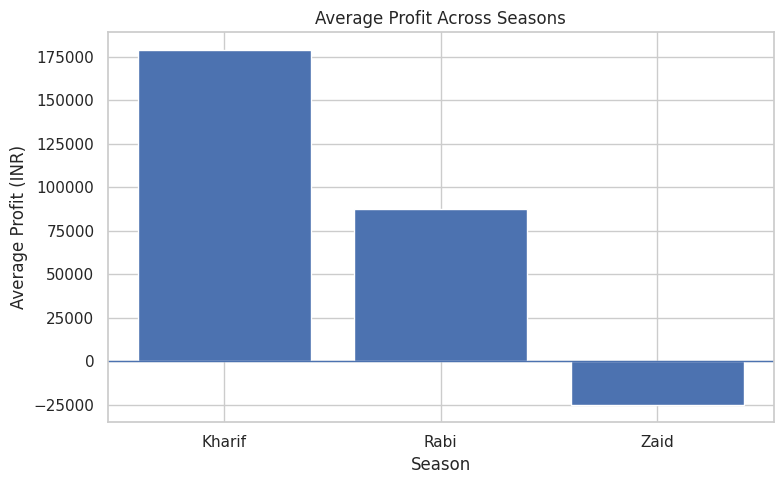

In [20]:
profit_by_season = df.groupby('Season')['Profit_INR'].mean()

plt.figure(figsize=(8, 5))

plt.bar(profit_by_season.index, profit_by_season.values)

plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [21]:
season_summary = df.groupby('Season').agg(
    Average_Yield_Tonnes_Ha=('Yield_Tonnes_Ha', 'mean'),
    Average_Production_Tonnes=('Production_Tonnes', 'mean'),
    Average_Profit_INR=('Profit_INR', 'mean')
).round(2)

season_summary

,Average_Yield_Tonnes_Ha,Average_Production_Tonnes,Average_Profit_INR
Season,,,
Kharif,5.63,46.31,"178,914.65"
Rabi,5.04,41.49,"87,689.47"
Zaid,4.64,38.89,"-24,804.82"


In [22]:
rainfall_by_season = df.groupby('Season')['Rainfall_mm'].mean().round(2)

print("Average rainfall by season:")
print(rainfall_by_season)

Average rainfall by season:
Season
Kharif   849.20
Rabi     437.62
Zaid     304.65
Name: Rainfall_mm, dtype: float64


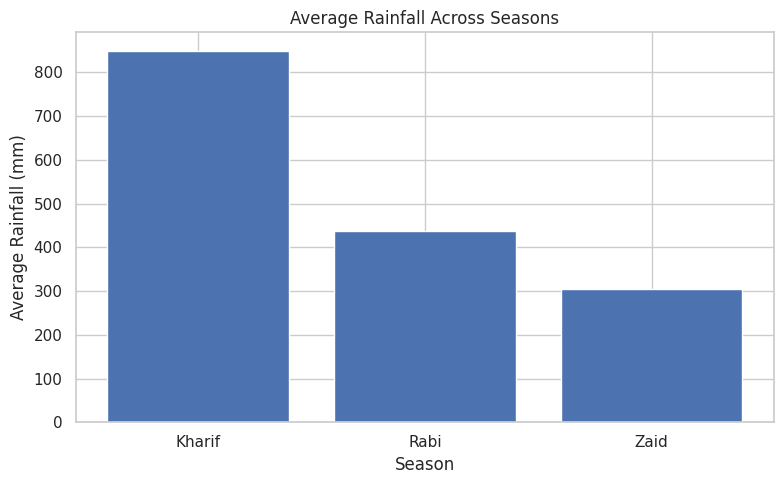

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(rainfall_by_season.index, rainfall_by_season.values)

plt.title('Average Rainfall Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')

plt.tight_layout()
plt.show()

In [24]:
temperature_by_season = df.groupby('Season')['Avg_Temperature_C'].mean().round(2)

print("Average temperature by season:")
print(temperature_by_season)

Average temperature by season:
Season
Kharif   28.45
Rabi     23.49
Zaid     31.04
Name: Avg_Temperature_C, dtype: float64


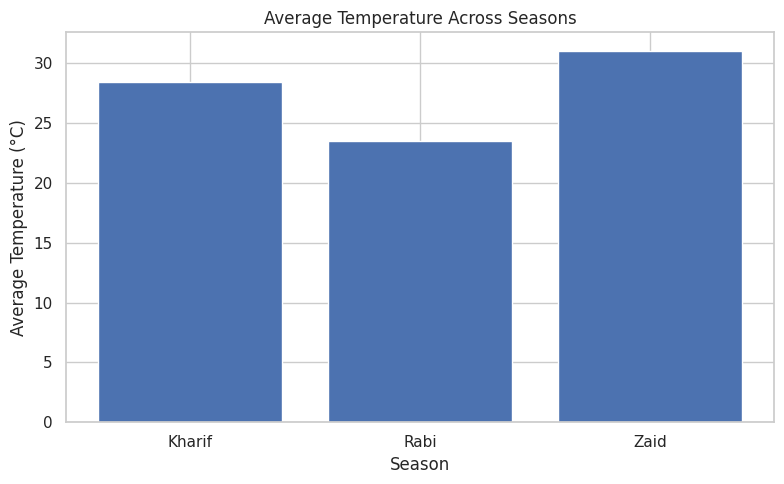

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(temperature_by_season.index, temperature_by_season.values)

plt.title('Average Temperature Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')

plt.tight_layout()
plt.show()

In [26]:
humidity_by_season = df.groupby('Season')['Humidity_pct'].mean().round(2)

print("Average humidity by season:")
print(humidity_by_season)

Average humidity by season:
Season
Kharif   71.81
Rabi     57.89
Zaid     52.01
Name: Humidity_pct, dtype: float64


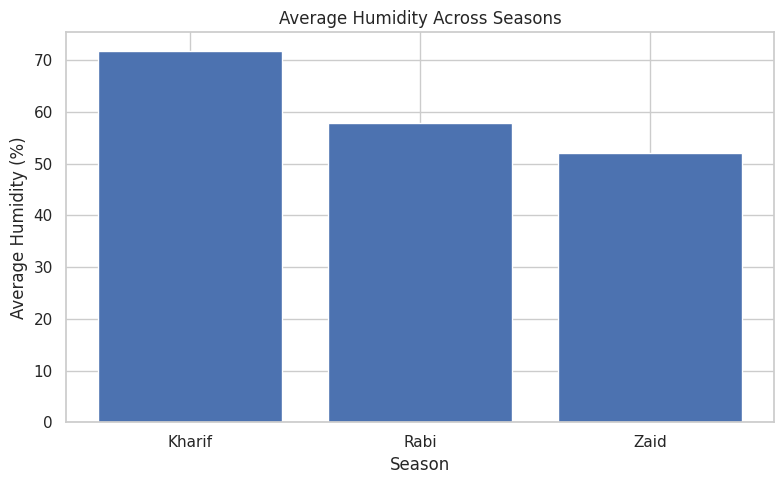

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(humidity_by_season.index, humidity_by_season.values)

plt.title('Average Humidity Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Humidity (%)')

plt.tight_layout()
plt.show()

In [28]:
sunlight_by_season = df.groupby('Season')['Sunlight_Hours_Day'].mean().round(2)

print("Average sunlight hours per day by season:")
print(sunlight_by_season)

Average sunlight hours per day by season:
Season
Kharif   6.79
Rabi     7.59
Zaid     8.18
Name: Sunlight_Hours_Day, dtype: float64


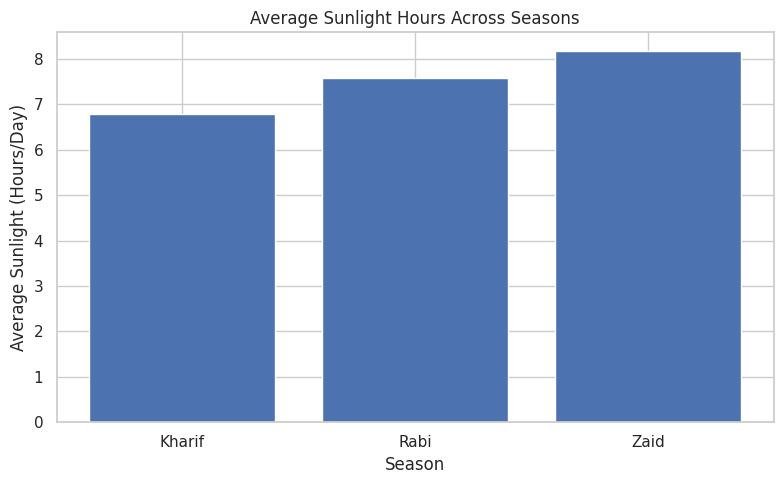

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(sunlight_by_season.index, sunlight_by_season.values)

plt.title('Average Sunlight Hours Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Sunlight (Hours/Day)')

plt.tight_layout()
plt.show()

In [30]:
environment_summary = df.groupby('Season').agg(
    Average_Rainfall_mm=('Rainfall_mm', 'mean'),
    Average_Temperature_C=('Avg_Temperature_C', 'mean'),
    Average_Humidity_pct=('Humidity_pct', 'mean'),
    Average_Sunlight_Hours=('Sunlight_Hours_Day', 'mean')
).round(2)

environment_summary

,Average_Rainfall_mm,Average_Temperature_C,Average_Humidity_pct,Average_Sunlight_Hours
Season,,,,
Kharif,849.20,28.45,71.81,6.79
Rabi,437.62,23.49,57.89,7.59
Zaid,304.65,31.04,52.01,8.18


In [31]:
water_by_season = df.groupby('Season')['Water_Used_m3'].mean().round(2)

print("Average water usage by season:")
print(water_by_season)

Average water usage by season:
Season
Kharif   6,102.20
Rabi     5,846.99
Zaid     6,419.89
Name: Water_Used_m3, dtype: float64


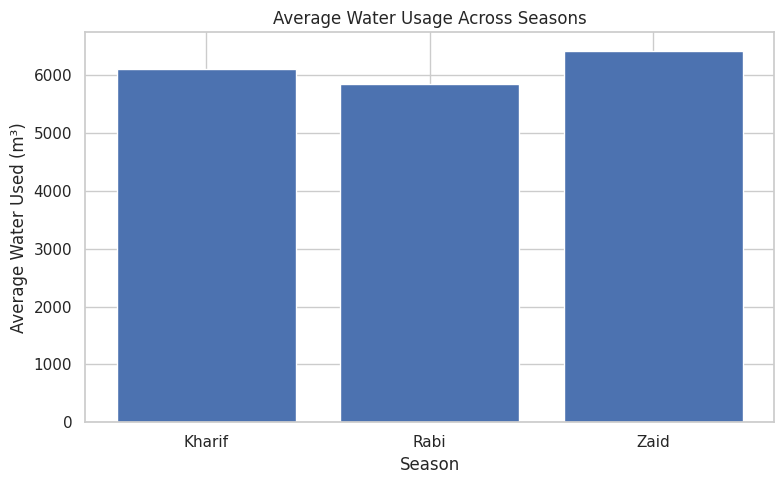

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(water_by_season.index, water_by_season.values)

plt.title('Average Water Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')

plt.tight_layout()
plt.show()

In [33]:
fertilizer_by_season = df.groupby('Season')['Fertilizer_kg_ha'].mean().round(2)

print("Average fertilizer usage by season:")
print(fertilizer_by_season)

Average fertilizer usage by season:
Season
Kharif   187.08
Rabi     185.41
Zaid     184.64
Name: Fertilizer_kg_ha, dtype: float64


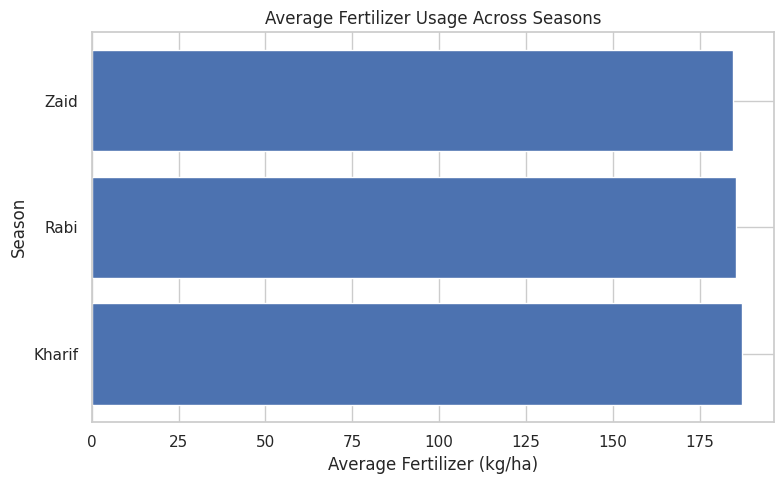

In [34]:
plt.figure(figsize=(8, 5))

plt.barh(
    fertilizer_by_season.index,
    fertilizer_by_season.values
)

plt.title('Average Fertilizer Usage Across Seasons')
plt.xlabel('Average Fertilizer (kg/ha)')
plt.ylabel('Season')

plt.tight_layout()
plt.show()

In [35]:
npk_by_season = df.groupby('Season')[
    ['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']
].mean().round(2)

npk_by_season

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,
Kharif,120.02,58.10,105.30
Rabi,120.40,57.31,103.93
Zaid,120.53,58.13,105.42


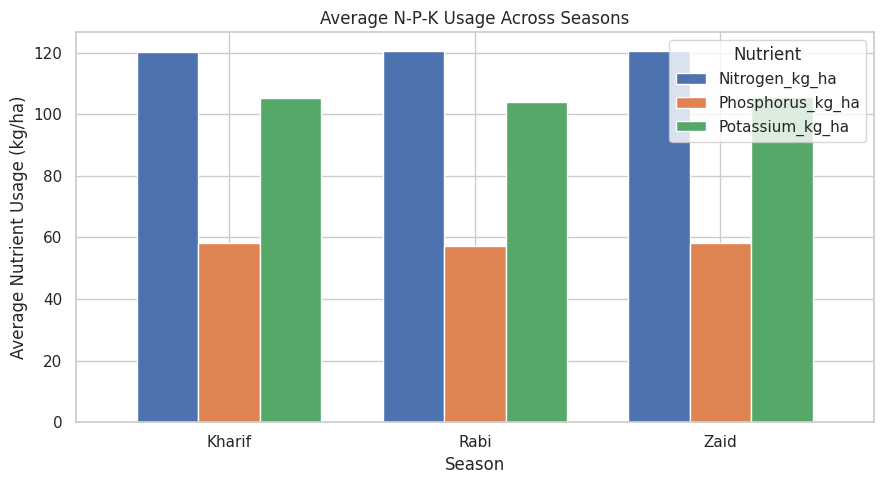

In [36]:
ax = npk_by_season.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.75
)

plt.title('Average N-P-K Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Nutrient Usage (kg/ha)')
plt.xticks(rotation=0)
plt.legend(title='Nutrient')

plt.tight_layout()
plt.show()

In [37]:
pesticide_by_season = df.groupby('Season')['Pesticide_Litre_ha'].mean().round(2)

print("Average pesticide usage by season:")
print(pesticide_by_season)

Average pesticide usage by season:
Season
Kharif   5.08
Rabi     5.02
Zaid     5.17
Name: Pesticide_Litre_ha, dtype: float64


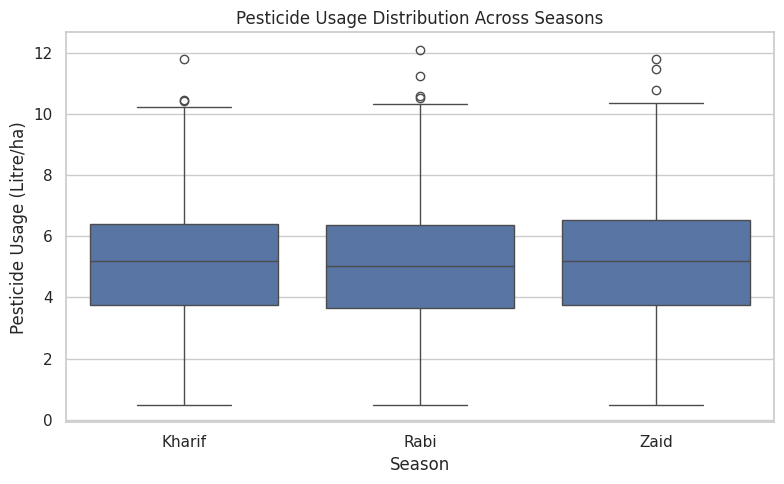

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Season',
    y='Pesticide_Litre_ha'
)

plt.title('Pesticide Usage Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Pesticide Usage (Litre/ha)')

plt.tight_layout()
plt.show()

In [39]:
irrigation_counts = df['Irrigation_Method'].value_counts()

print("Irrigation method distribution:")
print(irrigation_counts)

Irrigation method distribution:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


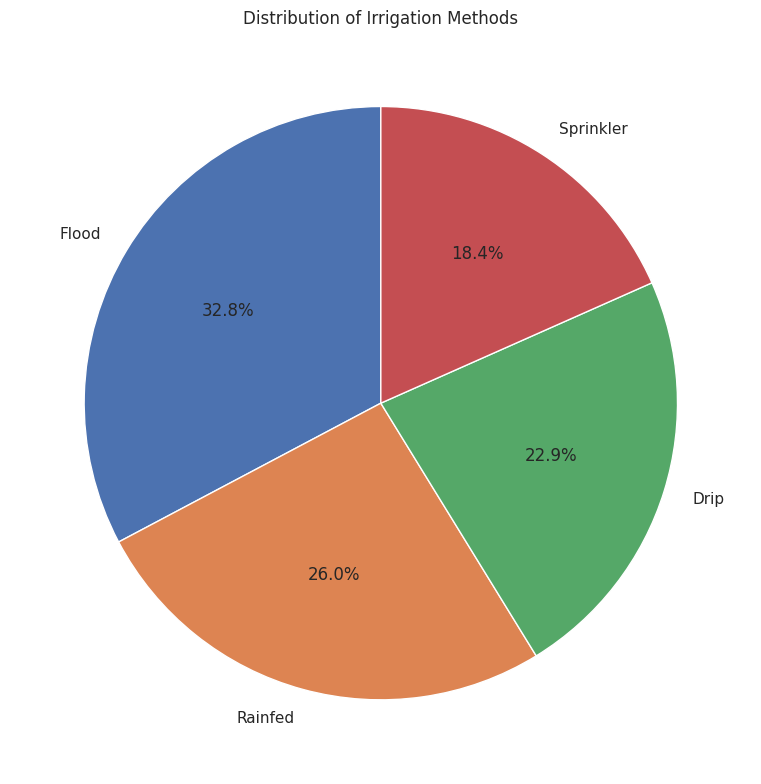

In [40]:
plt.figure(figsize=(8, 8))

plt.pie(
    irrigation_counts.values,
    labels=irrigation_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Irrigation Methods')

plt.tight_layout()
plt.show()

In [41]:
irrigation_yield = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().round(2)

print("Average yield by irrigation method:")
print(irrigation_yield)

Average yield by irrigation method:
Irrigation_Method
Drip        6.58
Flood       4.86
Rainfed     4.60
Sprinkler   5.16
Name: Yield_Tonnes_Ha, dtype: float64


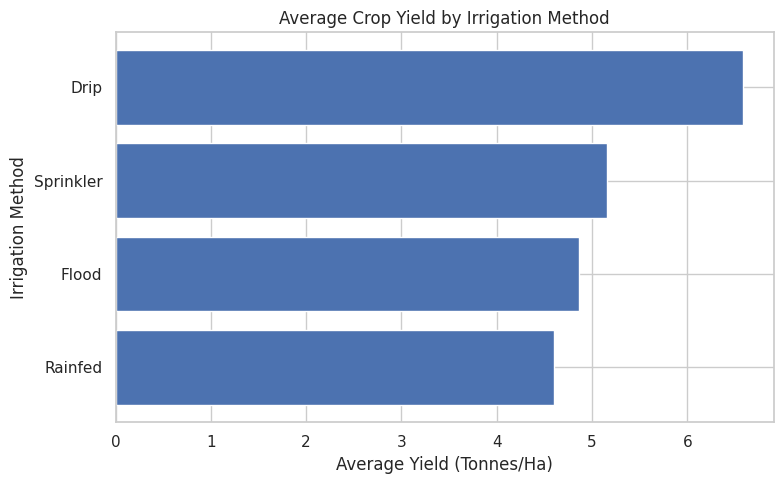

In [42]:
irrigation_yield_sorted = irrigation_yield.sort_values()

plt.figure(figsize=(8, 5))

plt.barh(
    irrigation_yield_sorted.index,
    irrigation_yield_sorted.values
)

plt.title('Average Crop Yield by Irrigation Method')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Irrigation Method')

plt.tight_layout()
plt.show()

In [43]:
water_efficiency_by_season = df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean().round(2)

print("Average water efficiency by season:")
print(water_efficiency_by_season)

Average water efficiency by season:
Season
Kharif   5.89
Rabi     5.19
Zaid     4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64


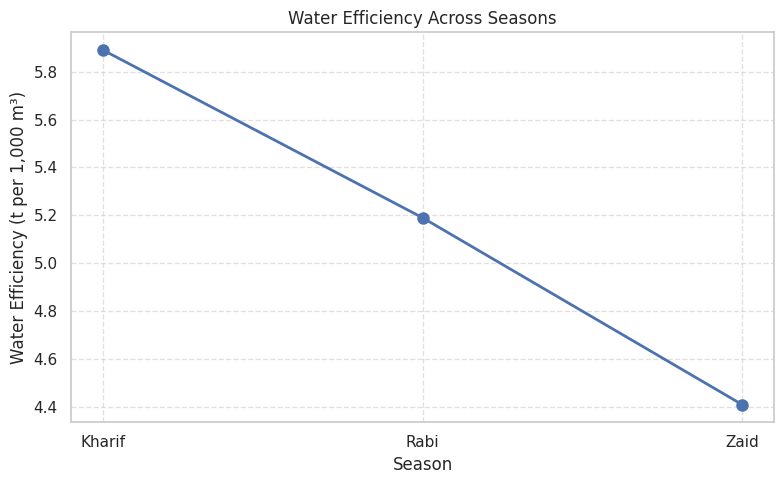

In [44]:
season_order = ['Kharif', 'Rabi', 'Zaid']

efficiency_values = water_efficiency_by_season.reindex(season_order)

plt.figure(figsize=(8, 5))

plt.plot(
    efficiency_values.index,
    efficiency_values.values,
    marker='o',
    linewidth=2,
    markersize=8
)

plt.title('Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (t per 1,000 m³)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [45]:
resource_summary = df.groupby('Season').agg(
    Average_Water_Used_m3=('Water_Used_m3', 'mean'),
    Average_Fertilizer_kg_ha=('Fertilizer_kg_ha', 'mean'),
    Average_Pesticide_Litre_ha=('Pesticide_Litre_ha', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2)

resource_summary

,Average_Water_Used_m3,Average_Fertilizer_kg_ha,Average_Pesticide_Litre_ha,Average_Water_Efficiency
Season,,,,
Kharif,"6,102.20",187.08,5.08,5.89
Rabi,"5,846.99",185.41,5.02,5.19
Zaid,"6,419.89",184.64,5.17,4.41


In [46]:
economic_summary = df.groupby('Season').agg(
    Average_Market_Price_INR_Tonne=('Market_Price_INR_Tonne', 'mean'),
    Average_Total_Cost_INR=('Total_Cost_INR', 'mean'),
    Average_Revenue_INR=('Revenue_INR', 'mean'),
    Average_Profit_INR=('Profit_INR', 'mean')
).round(2)

economic_summary

,Average_Market_Price_INR_Tonne,Average_Total_Cost_INR,Average_Revenue_INR,Average_Profit_INR
Season,,,,
Kharif,"44,850.91","531,804.41","710,719.06","178,914.65"
Rabi,"44,747.97","513,836.58","601,526.05","87,689.47"
Zaid,"44,212.03","543,976.73","519,171.90","-24,804.82"


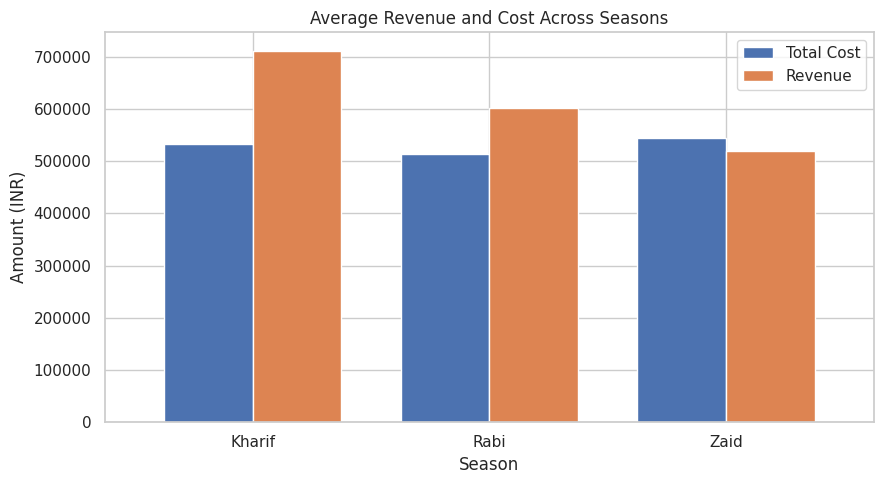

In [47]:
economic_comparison = economic_summary[
    ['Average_Total_Cost_INR', 'Average_Revenue_INR']
]

ax = economic_comparison.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.75
)

plt.title('Average Revenue and Cost Across Seasons')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.legend(['Total Cost', 'Revenue'])

plt.tight_layout()
plt.show()

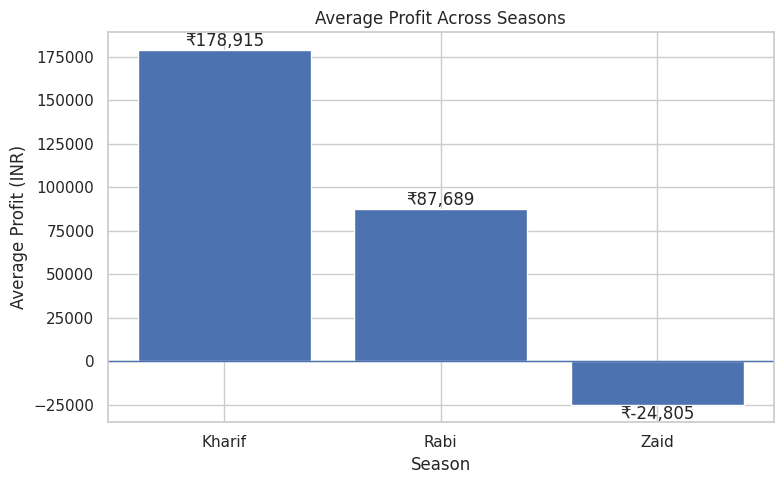

In [48]:
profit_by_season = economic_summary['Average_Profit_INR']

plt.figure(figsize=(8, 5))

bars = plt.bar(
    profit_by_season.index,
    profit_by_season.values
)

plt.axhline(0, linewidth=1)

plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

for bar, value in zip(bars, profit_by_season.values):
    if value >= 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f'₹{value:,.0f}',
            ha='center',
            va='bottom'
        )
    else:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f'₹{value:,.0f}',
            ha='center',
            va='top'
        )

plt.tight_layout()
plt.show()

In [49]:
economic_final = df.groupby('Season').agg(
    Average_Market_Price_INR_Tonne=('Market_Price_INR_Tonne', 'mean'),
    Average_Total_Cost_INR=('Total_Cost_INR', 'mean'),
    Average_Revenue_INR=('Revenue_INR', 'mean'),
    Average_Profit_INR=('Profit_INR', 'mean')
).round(2)

economic_final

,Average_Market_Price_INR_Tonne,Average_Total_Cost_INR,Average_Revenue_INR,Average_Profit_INR
Season,,,,
Kharif,"44,850.91","531,804.41","710,719.06","178,914.65"
Rabi,"44,747.97","513,836.58","601,526.05","87,689.47"
Zaid,"44,212.03","543,976.73","519,171.90","-24,804.82"


In [50]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False).round(2)

print("Average crop yield:")
print(crop_yield)

Average crop yield:
Crop
Sugarcane   46.64
Maize        2.71
Rice         2.43
Wheat        2.11
Chilli       1.54
Groundnut    1.32
Cotton       1.23
Pulses       0.92
Name: Yield_Tonnes_Ha, dtype: float64


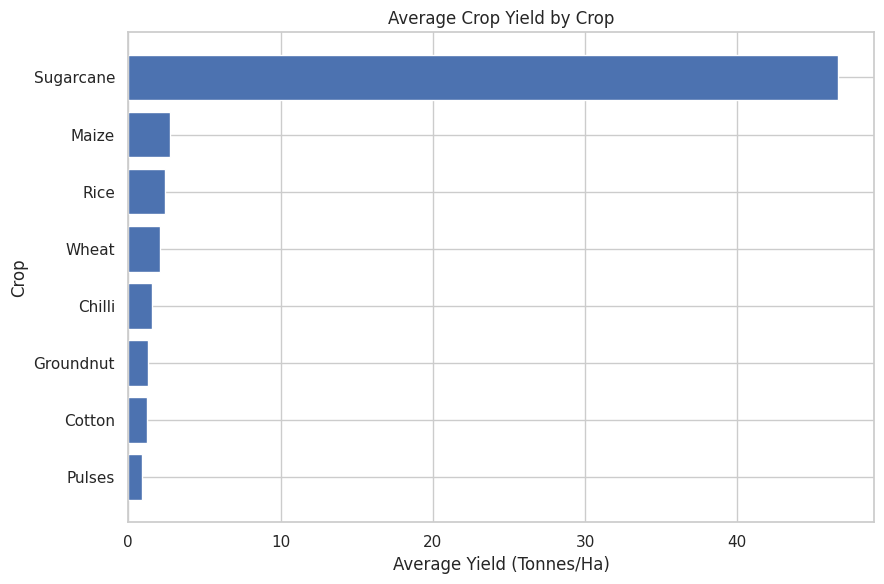

In [51]:
plt.figure(figsize=(9, 6))

plt.barh(
    crop_yield.index[::-1],
    crop_yield.values[::-1]
)

plt.title('Average Crop Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [52]:
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(2)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


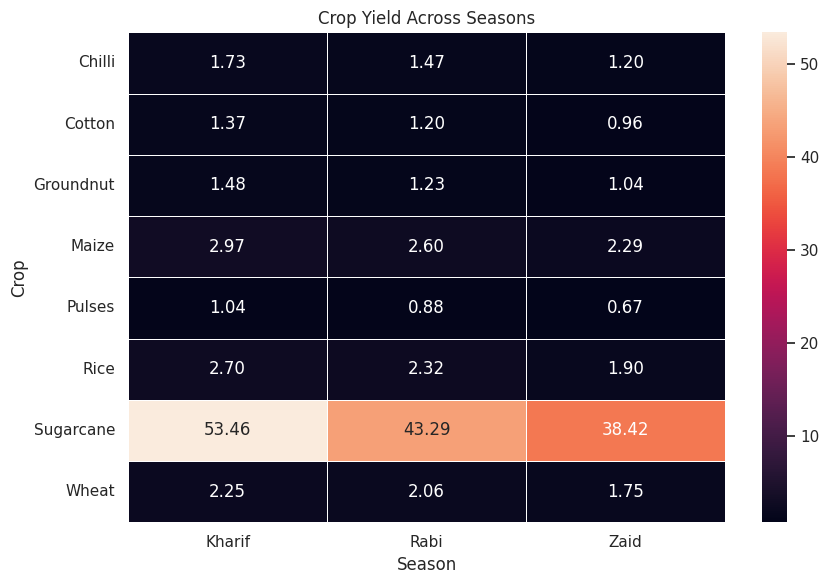

In [53]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [54]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False).round(2)

print("Average profit by crop:")
print(crop_profit)

Average profit by crop:
Crop
Sugarcane    817,187.99
Chilli       750,878.34
Cotton       124,546.92
Groundnut     44,858.12
Pulses        -4,238.05
Maize        -83,978.33
Rice        -102,213.50
Wheat       -123,398.34
Name: Profit_INR, dtype: float64


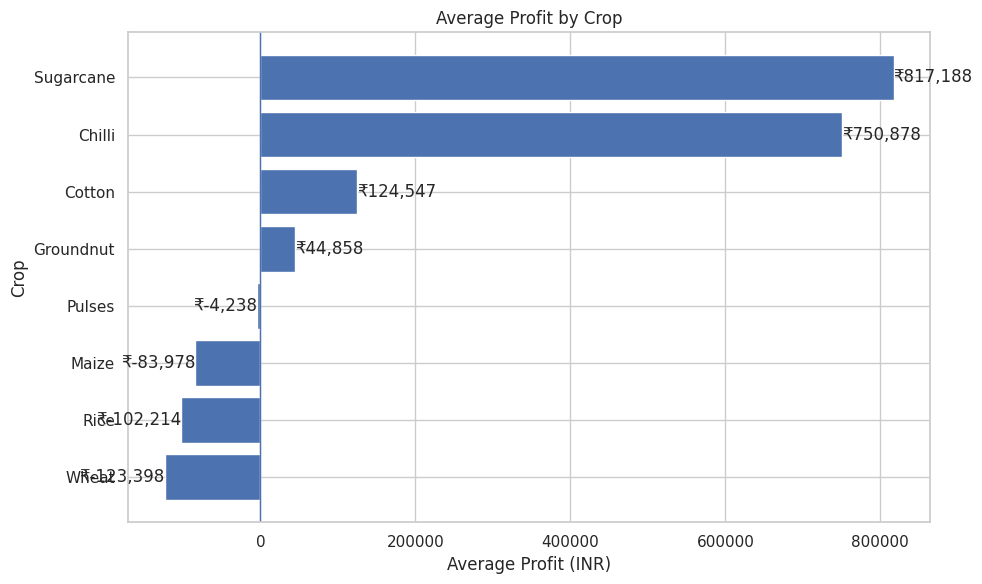

In [55]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    crop_profit.index[::-1],
    crop_profit.values[::-1]
)

# Zero reference line
plt.axvline(0, linewidth=1)

plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')

# Add profit values
for bar, value in zip(bars, crop_profit.values[::-1]):
    if value >= 0:
        plt.text(
            value,
            bar.get_y() + bar.get_height() / 2,
            f'₹{value:,.0f}',
            va='center',
            ha='left'
        )
    else:
        plt.text(
            value,
            bar.get_y() + bar.get_height() / 2,
            f'₹{value:,.0f}',
            va='center',
            ha='right'
        )

plt.tight_layout()
plt.show()

In [56]:
crop_season_profit = df.pivot_table(
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(2)

crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"954,380.42","638,572.50","448,659.09"
Cotton,"216,999.55","107,343.59","-53,925.34"
Groundnut,"108,265.44","10,416.54","-68,872.50"
Maize,"-39,332.67","-89,133.40","-194,049.17"
Pulses,"43,338.90","-14,309.14","-139,227.81"
Rice,"-64,903.40","-98,427.87","-227,239.34"
Sugarcane,"1,000,790.81","731,612.86","583,635.80"
Wheat,"-105,871.87","-119,954.57","-193,208.95"


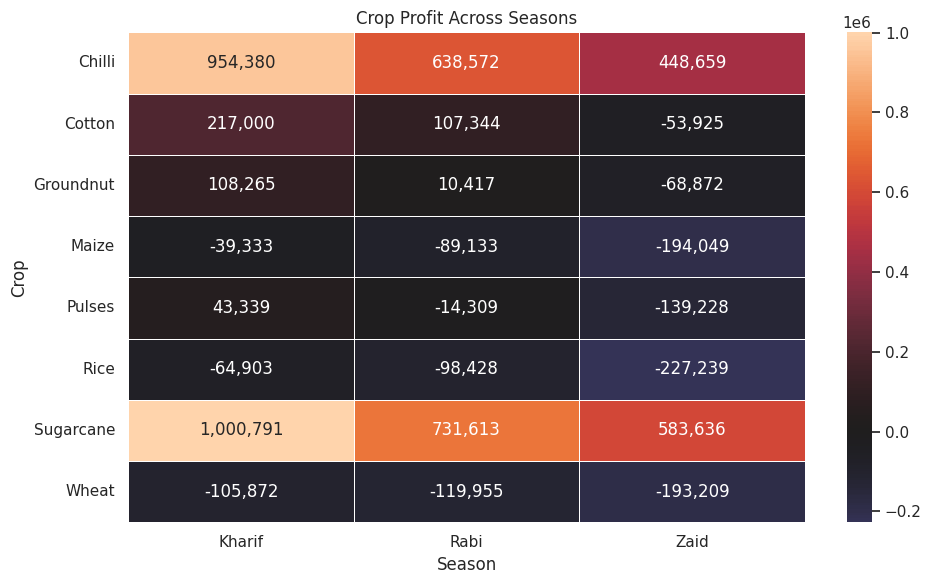

In [57]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt=',.0f',
    linewidths=0.5,
    center=0
)

plt.title('Crop Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [58]:
state_yield = df.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
).round(2)

print("Average yield by state:")
print(state_yield)

Average yield by state:
State
Punjab           6.12
Karnataka        5.69
Gujarat          5.66
Telangana        5.04
Maharashtra      5.02
Madhya Pradesh   4.99
Tamil Nadu       4.88
Andhra Pradesh   4.63
Name: Yield_Tonnes_Ha, dtype: float64


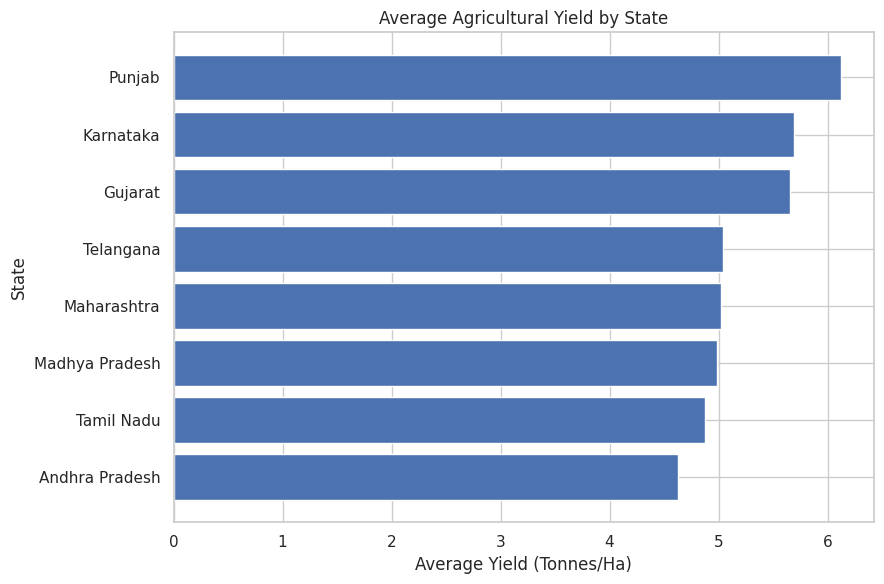

In [59]:
plt.figure(figsize=(9, 6))

plt.barh(
    state_yield.index[::-1],
    state_yield.values[::-1]
)

plt.title('Average Agricultural Yield by State')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [60]:
state_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
).round(2)

state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


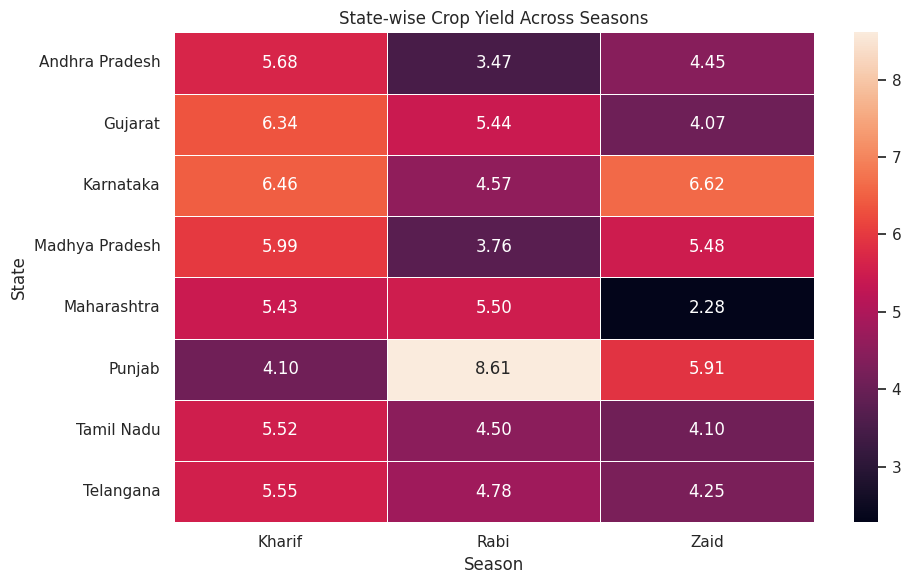

In [61]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title('State-wise Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [62]:
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(
    ascending=False
).round(2)

print("Average profit by state:")
print(state_profit)

Average profit by state:
State
Punjab           136,025.64
Maharashtra      135,428.86
Karnataka        119,422.34
Tamil Nadu       117,744.75
Gujarat          117,568.24
Telangana        108,829.62
Madhya Pradesh    86,840.76
Andhra Pradesh    73,453.53
Name: Profit_INR, dtype: float64


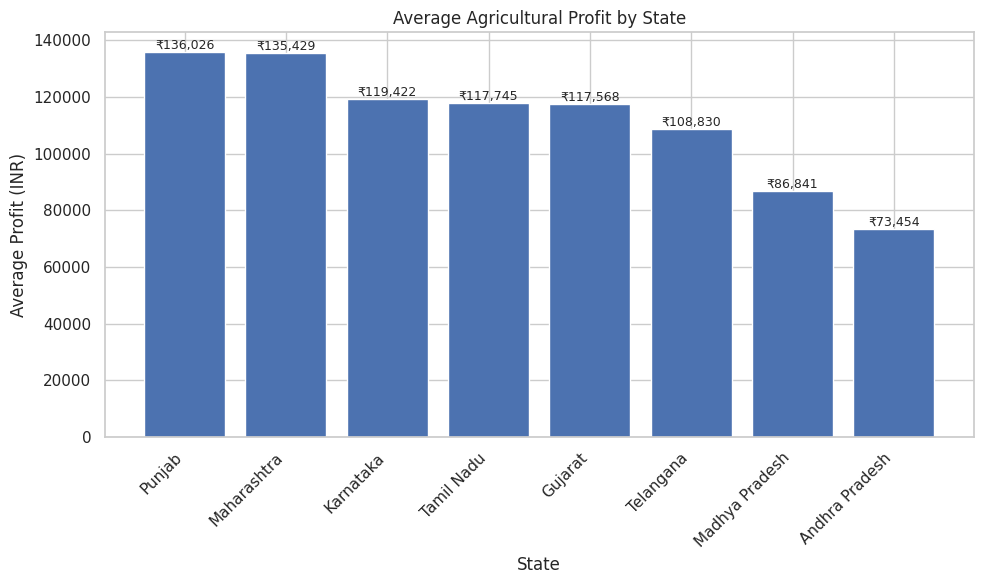

In [63]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    state_profit.index,
    state_profit.values
)

plt.title('Average Agricultural Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45, ha='right')

# Add values on top of bars
for bar, value in zip(bars, state_profit.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'₹{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [64]:
state_season_profit = df.pivot_table(
    values='Profit_INR',
    index='State',
    columns='Season',
    aggfunc='mean'
).round(2)

state_season_profit

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,"169,315.52","26,315.71","-84,084.87"
Gujarat,"217,051.33","82,846.20","-106,929.61"
Karnataka,"201,226.21","70,952.61","23,310.91"
Madhya Pradesh,"134,242.40","61,576.26",209.70
Maharashtra,"168,801.05","159,581.50","-40,597.60"
Punjab,"133,779.10","169,294.52","62,109.69"
Tamil Nadu,"211,303.96","70,456.86","-15,175.20"
Telangana,"199,668.38","62,824.60","-34,620.78"


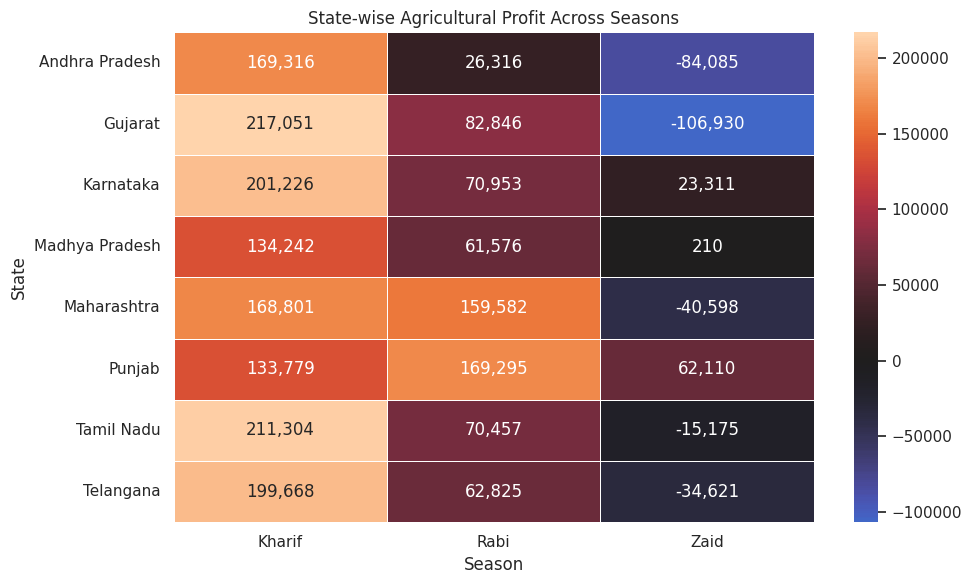

In [65]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    state_season_profit,
    annot=True,
    fmt=',.0f',
    linewidths=0.5,
    center=0
)

plt.title('State-wise Agricultural Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('State')

plt.tight_layout()
plt.show()

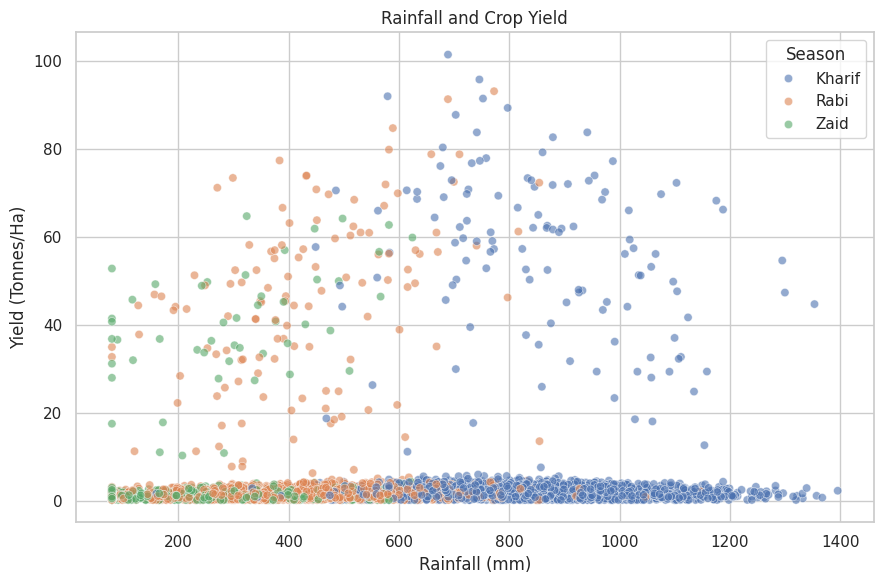

In [66]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Rainfall and Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Season')

plt.tight_layout()
plt.show()

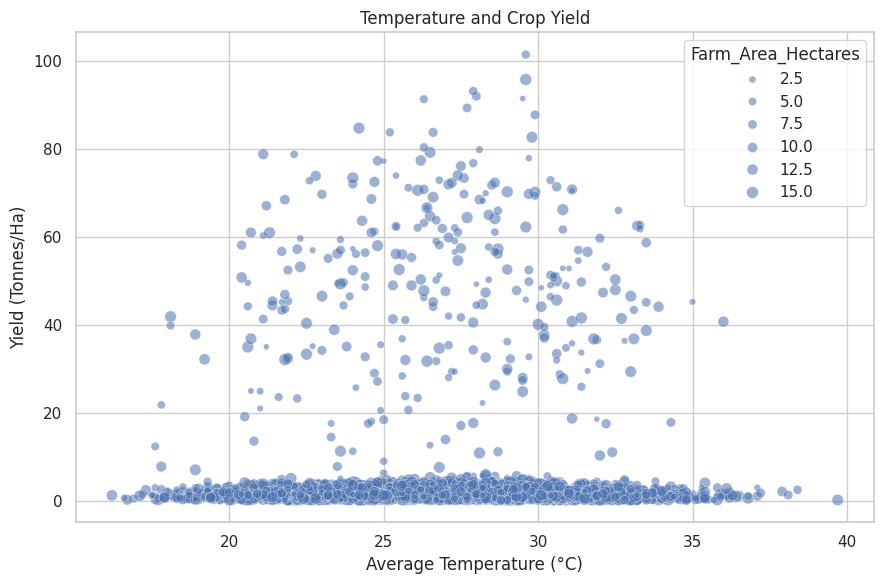

In [67]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    size='Farm_Area_Hectares',
    alpha=0.55
)

plt.title('Temperature and Crop Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [68]:
correlation_variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR'
]

correlation_table = df[correlation_variables].corr().round(2)

correlation_table

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Water_Used_m3,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Rainfall_mm,1.00,0.20,0.52,-0.36,0.51,0.02,0.00,-0.02,0.00,0.03,0.02,0.11
Avg_Temperature_C,0.20,1.00,0.14,-0.03,0.08,0.02,0.01,-0.03,0.02,0.01,0.01,0.01
Humidity_pct,0.52,0.14,1.00,-0.30,0.45,0.02,-0.00,-0.05,-0.00,0.01,0.00,0.06
Sunlight_Hours_Day,-0.36,-0.03,-0.30,1.00,-0.30,-0.01,-0.02,0.02,-0.01,-0.02,-0.02,-0.05
Soil_Moisture_pct,0.51,0.08,0.45,-0.30,1.00,0.01,-0.02,-0.02,0.00,0.01,0.00,0.09
Fertilizer_kg_ha,0.02,0.02,0.02,-0.01,0.01,1.00,-0.00,0.02,0.00,0.00,0.00,-0.07
Pesticide_Litre_ha,0.00,0.01,-0.00,-0.02,-0.02,-0.00,1.00,-0.00,0.00,-0.01,-0.01,-0.03
Seed_Quality_Score,-0.02,-0.03,-0.05,0.02,-0.02,0.02,-0.00,1.00,0.02,-0.01,-0.00,0.01
Water_Used_m3,0.00,0.02,-0.00,-0.01,0.00,0.00,0.00,0.02,1.00,0.39,0.52,0.19
Yield_Tonnes_Ha,0.03,0.01,0.01,-0.02,0.01,0.00,-0.01,-0.01,0.39,1.00,0.88,0.49


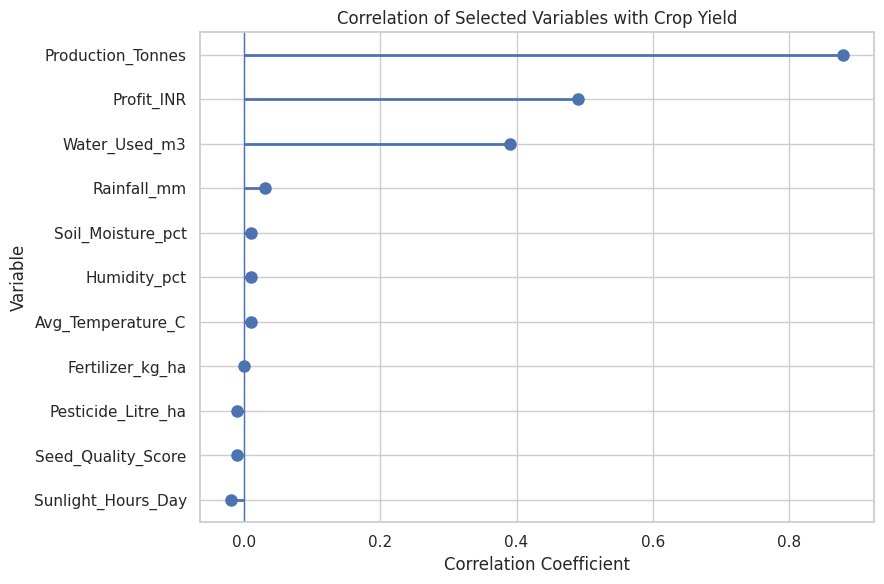

In [69]:
yield_correlations = correlation_table['Yield_Tonnes_Ha'].drop(
    'Yield_Tonnes_Ha'
).sort_values()

plt.figure(figsize=(9, 6))

plt.hlines(
    y=yield_correlations.index,
    xmin=0,
    xmax=yield_correlations.values,
    linewidth=2
)

plt.plot(
    yield_correlations.values,
    yield_correlations.index,
    'o',
    markersize=8
)

plt.axvline(0, linewidth=1)

plt.title('Correlation of Selected Variables with Crop Yield')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

In [70]:
kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

statistic, p_value = stats.kruskal(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("Kruskal-Wallis Test for Yield Across Seasons")
print(f"Test statistic: {statistic:.2f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: The difference in yield across seasons is statistically significant.")
else:
    print("Result: The difference in yield across seasons is not statistically significant.")

Kruskal-Wallis Test for Yield Across Seasons
Test statistic: 68.71
P-value: 0.000000
Result: The difference in yield across seasons is statistically significant.


In [71]:
seasonal_findings = df.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Rainfall=('Rainfall_mm', 'mean'),
    Average_Temperature=('Avg_Temperature_C', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2)

seasonal_findings

,Average_Yield,Average_Production,Average_Profit,Average_Rainfall,Average_Temperature,Average_Water_Used,Average_Water_Efficiency
Season,,,,,,,
Kharif,5.63,46.31,"178,914.65",849.20,28.45,"6,102.20",5.89
Rabi,5.04,41.49,"87,689.47",437.62,23.49,"5,846.99",5.19
Zaid,4.64,38.89,"-24,804.82",304.65,31.04,"6,419.89",4.41


## Significant and Unusual Seasonal Patterns

The analysis reveals several important differences in agricultural performance across seasons:

- Kharif records the highest average crop yield (5.63 tonnes/ha) and production (46.31 tonnes), while Zaid records the lowest values (4.64 tonnes/ha and 38.89 tonnes).
- Average profit varies considerably across seasons. Kharif shows the highest average profit of ₹178,914.65, whereas Zaid records an average loss of ₹24,804.82.
- Environmental conditions differ noticeably between seasons. Kharif has the highest average rainfall and humidity, while Zaid has the highest average temperature and sunlight duration.
- Zaid has the highest average water usage (6,419.89 m³) but the lowest water efficiency (4.41 t per 1,000 m³).
- Crop-level analysis shows that Sugarcane has substantially higher yield and profitability than the other crops in the dataset.
- The crop-season analysis shows that Kharif provides the highest average yield for every crop in the dataset, while Zaid provides the lowest yield for every crop.
- However, the state-wise analysis shows that seasonal performance is not uniform across regions. For example, Punjab performs best in Rabi, while Karnataka records its highest average yield in Zaid.
- Several crops become loss-making during Zaid, indicating that seasonal economic performance can vary substantially depending on the crop.
- The Kruskal-Wallis test provides statistical evidence that crop yield differs significantly across seasons (p < 0.05).
- Correlation analysis shows a strong positive relationship between yield and production, while environmental variables such as rainfall and temperature show very weak linear correlations with yield in this dataset.

## Key Findings

The overall analysis of the agricultural dataset produced the following major findings:

1. **Seasonal performance differs:** Kharif shows the highest average yield, production, and profit, while Zaid records the lowest average yield and an overall average loss.

2. **Environmental conditions vary by season:** Kharif has considerably higher rainfall and humidity, whereas Zaid has higher temperature and sunlight duration.

3. **Water usage and efficiency vary:** Zaid uses the highest average amount of water but has the lowest water efficiency among the three seasons.

4. **Crop performance differs substantially:** Sugarcane has the highest average yield and profit in the dataset, while Pulses has the lowest average yield.

5. **Seasonal crop performance is not uniform:** Although Kharif records the highest yield for all crops overall, state-level analysis shows that the best-performing season can differ between regions.

6. **Profitability varies by crop and season:** Sugarcane and Chilli remain highly profitable across seasons, while several crops experience losses, particularly during Zaid.

7. **Regional differences are present:** Average yield and profit vary across states, indicating that geographical location is associated with differences in agricultural performance within the dataset.

8. **Relationships between variables vary in strength:** Yield has a strong positive correlation with production and moderate positive correlations with profit and water usage. Several environmental and input variables show weak linear relationships with yield.

9. **Statistical analysis supports seasonal differences:** The Kruskal-Wallis test indicates that the observed differences in crop yield across seasons are statistically significant.

10. **Seasonal planning should consider multiple factors:** The findings indicate that crop choice, environmental conditions, resource usage, location, and economic performance should be considered together when evaluating seasonal agricultural performance.

## Data-driven Recommendations

Based on the observed seasonal, crop-wise, resource-wise, and regional patterns, the following recommendations can be made:

1. **Plan crop activities according to seasonal performance:** Since agricultural performance differs across seasons, seasonal planning should consider the observed yield and profitability patterns before selecting crops and farming activities.

2. **Consider regional differences in seasonal planning:** The best-performing season is not the same for every state. Therefore, agricultural planning should account for regional conditions rather than applying one seasonal strategy to all locations.

3. **Give attention to water efficiency:** Zaid shows the highest average water usage but the lowest water efficiency. Water management should therefore receive greater attention during periods with higher water consumption.

4. **Evaluate crop profitability along with yield:** High production does not necessarily guarantee positive financial outcomes. Crop selection should consider production costs, revenue, and profit together with yield.

5. **Review loss-making crop-season combinations:** Several crop-season combinations show negative average profit, particularly during Zaid. These combinations should be examined further for their cost, yield, market price, and resource-use characteristics.

6. **Consider crop-specific strategies:** Sugarcane and Chilli show strong profitability in the dataset, while several other crops show lower or negative average profits. Crop-specific planning may therefore be more useful than applying the same approach to every crop.

7. **Use multiple factors when evaluating performance:** The correlation analysis shows that environmental variables alone do not explain agricultural outcomes. Yield, production, resource usage, economic factors, and regional conditions should be considered together.

8. **Use data analysis for seasonal decision-making:** Regular comparison of seasonal yield, resource consumption, environmental conditions, and economic performance can help identify changing patterns and support evidence-based agricultural planning.

## Importance of the Analysis

Seasonal analysis helps understand how agricultural performance changes under different environmental, resource, and economic conditions. Comparing seasons can reveal important differences in crop yield, production, water usage, profitability, and regional performance. These insights can support better crop planning, resource management, and evidence-based seasonal decision-making.

## Conclusion

This project analyzed agricultural data from different seasons, crops, and geographical regions to understand variations in agricultural performance. The analysis covered data preparation, seasonal performance, environmental conditions, resource usage, economic outcomes, crop-wise differences, regional variations, relationships between variables, and statistical evidence.

The results show clear differences in agricultural performance across Kharif, Rabi, and Zaid seasons. Kharif recorded the highest average yield, production, and profit, while Zaid showed lower yield, higher water usage, lower water efficiency, and an overall average loss. Crop-wise and region-wise analysis further showed that performance varies considerably depending on the crop, season, and location.

Correlation analysis helped identify relationships among important agricultural variables, while the Kruskal-Wallis test provided statistical evidence that yield differs significantly across seasons.

Overall, the study demonstrates how data analytics and visualization can be used to identify seasonal patterns, compare agricultural performance, understand resource and economic variations, and support evidence-based seasonal planning. The findings can help highlight areas that require further investigation and more detailed agricultural analysis.

,Average Yield (tonnes/ha),Average Production (tonnes),Average Profit (INR)
Season,,,
Kharif,5.63,46.31,"178,914.65"
Rabi,5.04,41.49,"87,689.47"
Zaid,4.64,38.89,"-24,804.82"


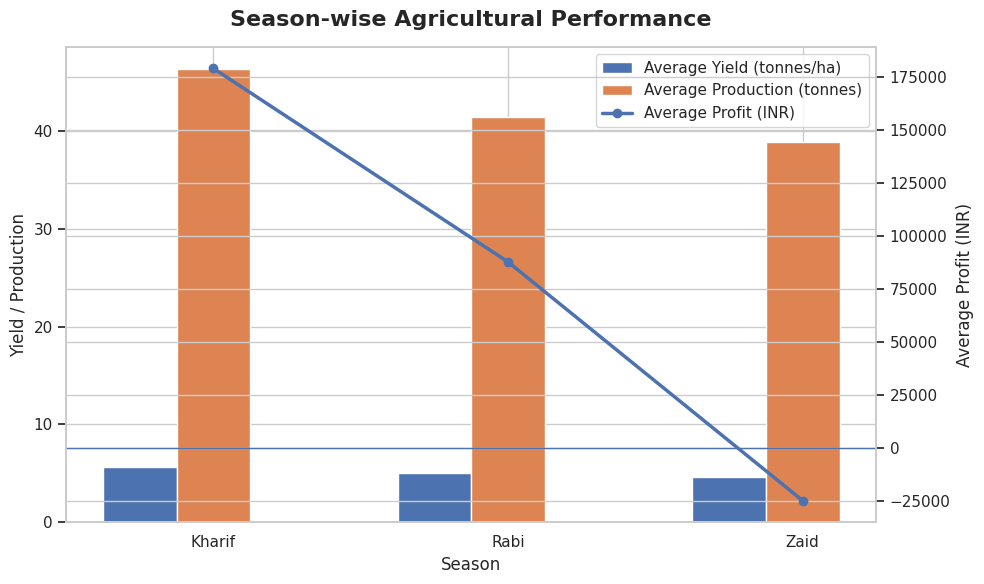

In [73]:
# Season-wise Agricultural Performance — Main Result

season_result = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean'
}).reindex(['Kharif', 'Rabi', 'Zaid'])

season_result.columns = [
    'Average Yield (tonnes/ha)',
    'Average Production (tonnes)',
    'Average Profit (INR)'
]

# Display result table
display(season_result.round(2))

# Create presentation-ready graph
fig, ax1 = plt.subplots(figsize=(10, 6))

seasons = season_result.index
x = np.arange(len(seasons))
width = 0.25

# Yield
bars1 = ax1.bar(
    x - width,
    season_result['Average Yield (tonnes/ha)'],
    width,
    label='Average Yield (tonnes/ha)'
)

# Production
bars2 = ax1.bar(
    x,
    season_result['Average Production (tonnes)'],
    width,
    label='Average Production (tonnes)'
)

ax1.set_xlabel('Season', fontsize=12)
ax1.set_ylabel('Yield / Production', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(seasons, fontsize=11)
ax1.set_title(
    'Season-wise Agricultural Performance',
    fontsize=16,
    fontweight='bold',
    pad=15
)

# Profit on second axis
ax2 = ax1.twinx()

ax2.plot(
    x,
    season_result['Average Profit (INR)'],
    marker='o',
    linewidth=2.5,
    label='Average Profit (INR)'
)

ax2.axhline(0, linewidth=1)
ax2.set_ylabel('Average Profit (INR)', fontsize=12)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

plt.tight_layout()
plt.show()

,Rainfall (mm),Temperature (°C),Humidity (%),Sunlight (hours/day)
Season,,,,
Kharif,849.20,28.45,71.81,6.79
Rabi,437.62,23.49,57.89,7.59
Zaid,304.65,31.04,52.01,8.18


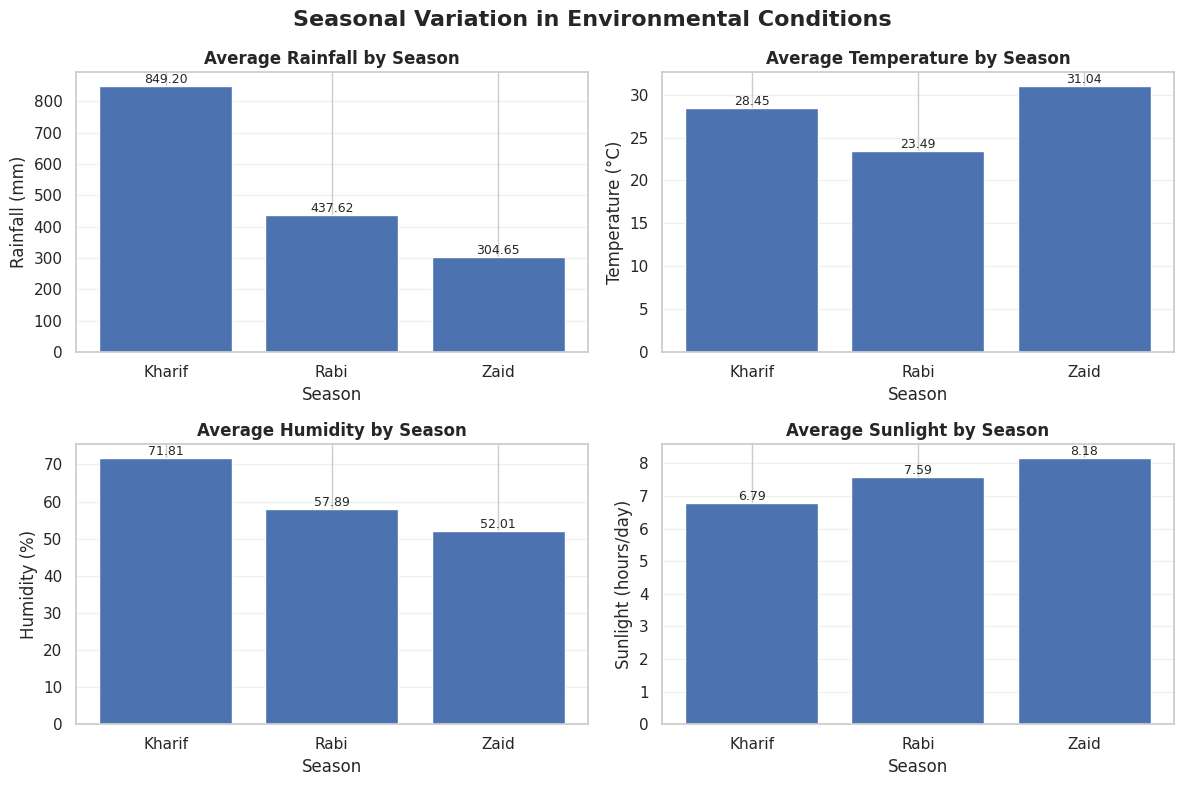

In [74]:
# Seasonal Environmental Conditions — Main Result

environment_result = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean'
}).reindex(['Kharif', 'Rabi', 'Zaid'])

environment_result.columns = [
    'Rainfall (mm)',
    'Temperature (°C)',
    'Humidity (%)',
    'Sunlight (hours/day)'
]

# Display result table
display(environment_result.round(2))

# Create presentation-ready graph
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metrics = [
    ('Rainfall (mm)', 'Average Rainfall by Season'),
    ('Temperature (°C)', 'Average Temperature by Season'),
    ('Humidity (%)', 'Average Humidity by Season'),
    ('Sunlight (hours/day)', 'Average Sunlight by Season')
]

for ax, (column, title) in zip(axes.flat, metrics):
    bars = ax.bar(
        environment_result.index,
        environment_result[column]
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel(column)
    ax.grid(axis='y', alpha=0.3)

    # Add values above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

fig.suptitle(
    'Seasonal Variation in Environmental Conditions',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

,Water Used (m³),Fertilizer (kg/ha),Pesticide (L/ha),Water Efficiency (t/1000m³)
Season,,,,
Kharif,"6,102.20",187.08,5.08,5.89
Rabi,"5,846.99",185.41,5.02,5.19
Zaid,"6,419.89",184.64,5.17,4.41


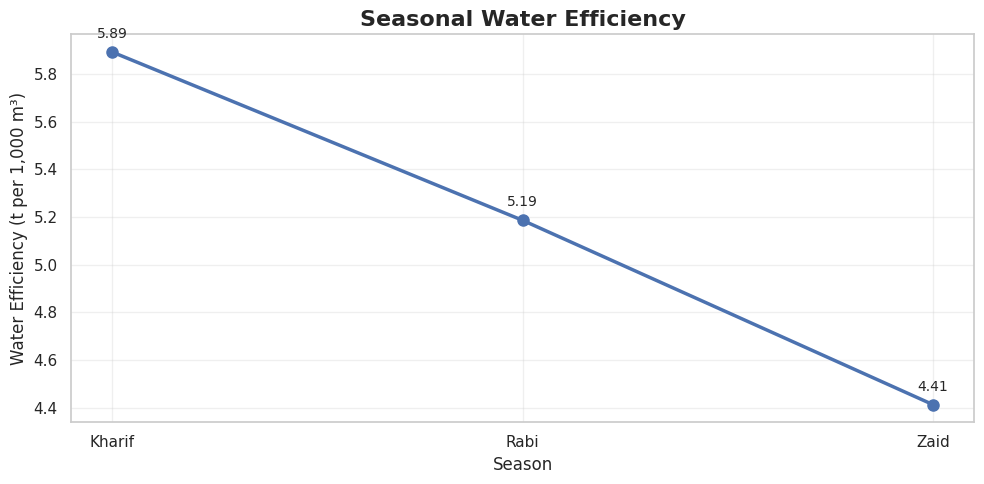

In [75]:
# Seasonal Resource Usage and Water Efficiency — Main Result

resource_result = df.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).reindex(['Kharif', 'Rabi', 'Zaid'])

resource_result.columns = [
    'Water Used (m³)',
    'Fertilizer (kg/ha)',
    'Pesticide (L/ha)',
    'Water Efficiency (t/1000m³)'
]

# Display exact results
display(resource_result.round(2))

# Water efficiency trend
plt.figure(figsize=(10, 5))

plt.plot(
    resource_result.index,
    resource_result['Water Efficiency (t/1000m³)'],
    marker='o',
    linewidth=2.5,
    markersize=8
)

for season, value in resource_result['Water Efficiency (t/1000m³)'].items():
    plt.annotate(
        f'{value:.2f}',
        (season, value),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10
    )

plt.title(
    'Seasonal Water Efficiency',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Season', fontsize=12)
plt.ylabel('Water Efficiency (t per 1,000 m³)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

,Number of Farms,Average Yield (tonnes/ha)
Irrigation_Method,,
Drip,915,6.58
Flood,1310,4.86
Rainfed,1041,4.60
Sprinkler,734,5.16


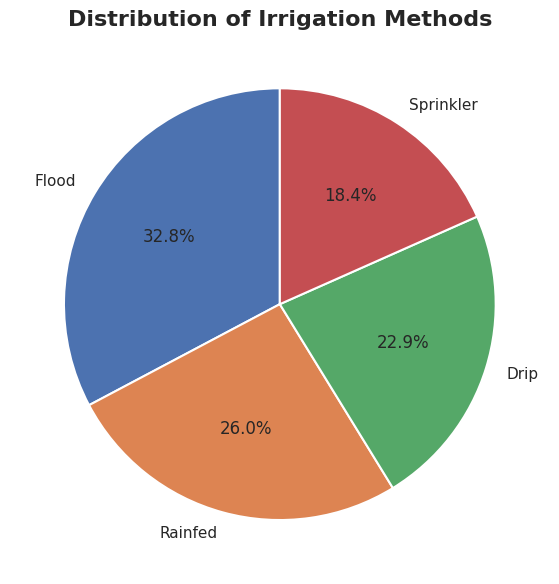

In [76]:
# Irrigation Method Distribution and Yield Analysis

irrigation_count = df['Irrigation_Method'].value_counts()

irrigation_yield = (
    df.groupby('Irrigation_Method')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

# Display exact results
irrigation_result = pd.DataFrame({
    'Number of Farms': irrigation_count,
    'Average Yield (tonnes/ha)': irrigation_yield
}).fillna(0)

display(irrigation_result.round(2))

# Create pie chart
plt.figure(figsize=(8, 6))

plt.pie(
    irrigation_count.values,
    labels=irrigation_count.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title(
    'Distribution of Irrigation Methods',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Season,Kharif,Rabi,Zaid,Overall Average Yield
Crop,,,,
Sugarcane,53.46,43.29,38.42,46.64
Maize,2.97,2.60,2.29,2.71
Rice,2.70,2.32,1.90,2.43
Wheat,2.25,2.06,1.75,2.11
Chilli,1.73,1.47,1.20,1.54
Groundnut,1.48,1.23,1.04,1.32
Cotton,1.37,1.20,0.96,1.23
Pulses,1.04,0.88,0.67,0.92


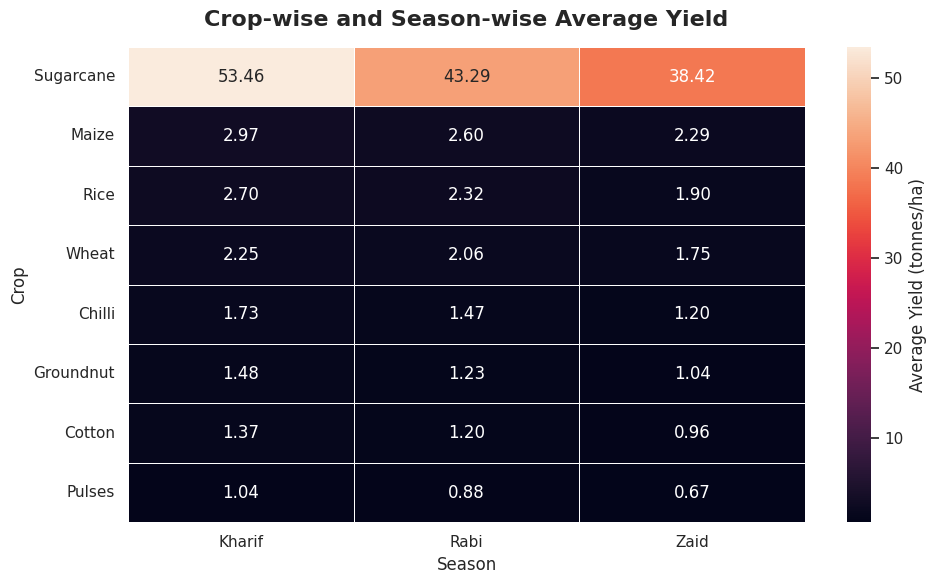

In [77]:
# Crop-wise and Season-wise Yield Analysis — Main Result

crop_season_result = (
    df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha']
    .mean()
    .unstack()
    .reindex(columns=['Kharif', 'Rabi', 'Zaid'])
)

# Add overall average yield for each crop
crop_season_result['Overall Average Yield'] = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
)

# Arrange crops from highest to lowest overall yield
crop_season_result = crop_season_result.sort_values(
    'Overall Average Yield',
    ascending=False
)

# Display result table
display(crop_season_result.round(2))

# Heatmap for seasonal comparison
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_result[['Kharif', 'Rabi', 'Zaid']],
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Average Yield (tonnes/ha)'}
)

plt.title(
    'Crop-wise and Season-wise Average Yield',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Season', fontsize=12)
plt.ylabel('Crop', fontsize=12)

plt.tight_layout()
plt.show()

,Average Yield (tonnes/ha)
State,
Andhra Pradesh,4.63
Tamil Nadu,4.88
Madhya Pradesh,4.99
Maharashtra,5.02
Telangana,5.04
Gujarat,5.66
Karnataka,5.69
Punjab,6.12


Kruskal-Wallis Test for Seasonal Yield Differences
Test Statistic: 68.71
p-value: 0.000000
Conclusion: Yield differences across seasons are statistically significant (p < 0.05).


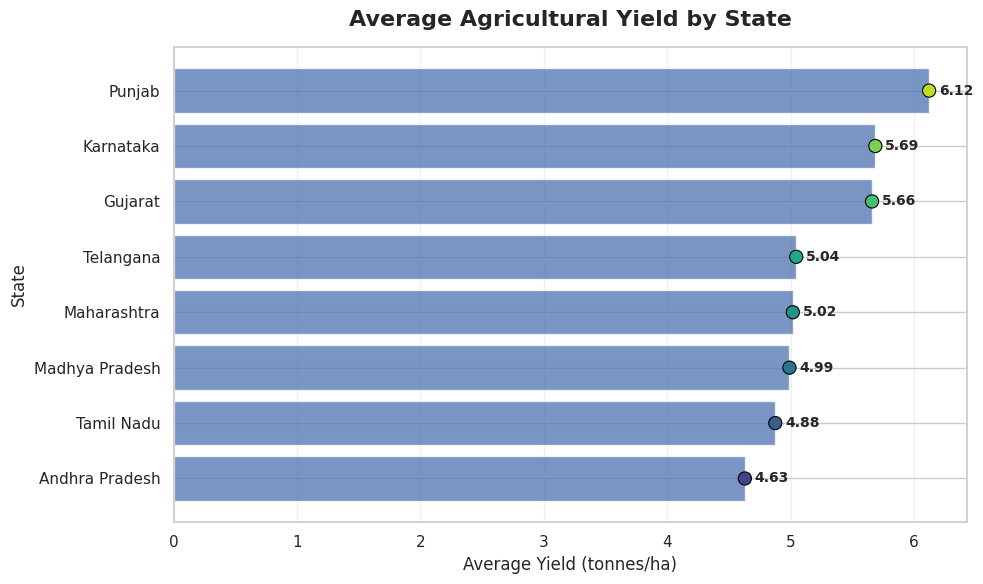

In [81]:
# Regional and Statistical Analysis — Final Result

# Overall average yield by state
state_yield_result = (
    df.groupby('State')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=True)
)

# Display result table
state_result_table = pd.DataFrame({
    'Average Yield (tonnes/ha)': state_yield_result
})

display(state_result_table.round(2))


# Kruskal-Wallis statistical test
kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

statistic, p_value = stats.kruskal(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("Kruskal-Wallis Test for Seasonal Yield Differences")
print(f"Test Statistic: {statistic:.2f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Conclusion: Yield differences across seasons are statistically significant (p < 0.05).")
else:
    print("Conclusion: No statistically significant difference was found across seasons (p >= 0.05).")


# Horizontal bar chart with colored dots
plt.figure(figsize=(10, 6))

bars = plt.barh(
    state_yield_result.index,
    state_yield_result.values,
    alpha=0.75
)

# Add colored dots at the end of each bar
dot_colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(state_yield_result))
)

plt.scatter(
    state_yield_result.values,
    state_yield_result.index,
    s=90,
    c=dot_colors,
    edgecolors='black',
    linewidths=0.8,
    zorder=3
)

# Add value labels
for state, value in state_yield_result.items():
    plt.text(
        value + 0.08,
        state,
        f'{value:.2f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.xlabel('Average Yield (tonnes/ha)', fontsize=12)
plt.ylabel('State', fontsize=12)

plt.title(
    'Average Agricultural Yield by State',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()